## قرايه الملف 

In [5]:


import pandas as pd 

df = pd.read_csv('apples_and_oranges.csv')

df 

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange
5,73,5.68,apple
6,70,5.56,apple
7,75,5.11,apple
8,74,5.36,apple
9,65,4.27,orange


## نرسم البيانات بشكل مرئيا 

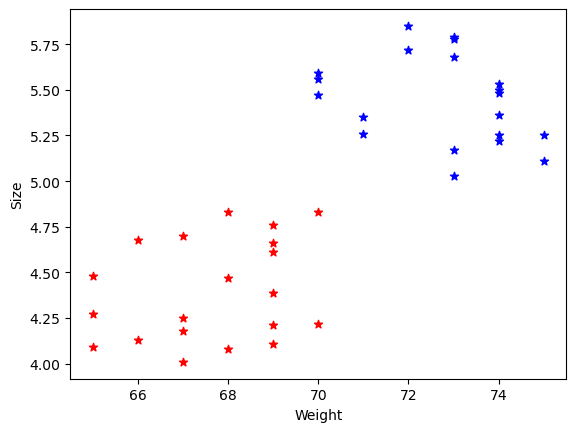

In [16]:
import matplotlib.pyplot as plt 

# الان نحدد الاكس و الواي في الرسم البياني 

plt.xlabel('Weight')

plt.ylabel('Size')

# الان عن طريق query راح نحدد نقاط بيانات البرتقال 

dforange = df.query("Class =='orange'")
dfapple = df.query("Class =='apple'")

# الان راح نرسم بطريقه scatter 

plt.scatter(dforange['Weight'],dforange['Size'], color = 'red' , marker = '*')
plt.scatter(dfapple['Weight'],dfapple['Size'], color = 'blue' , marker = '*')

# لو تلاحظ ان في امكانيه تمرير خط يفصل بين البيانات يعني راح نستخدم linear svm 

##  راح نحدد عمود الدخل و عمود الخرج 

In [17]:
x = df[['Weight','Size']]
y = df['Class']

## لازم نحول عمود class عشانه نصي 

In [18]:
from sklearn.preprocessing import LabelEncoder

label_gender = LabelEncoder ()

y = label_gender.fit_transform(y)

y

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0])

## راح نقسم البيانات الى تدريب و اختبار 

In [19]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x , y , train_size = 0.8 , random_state = 0 )

## الان راح نسوي svm 

In [40]:
from sklearn.svm import SVC

model = SVC()

model.fit(x_train.values , y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## الحين نتنبئ 

In [41]:
y_pred = model.predict(x_test.values)

## الان نقيس التنبؤ 

In [42]:
from sklearn import metrics 
# اضربها بالميه عشان تطلع النسبه 
# نحسب accuracy 
accuracy = 100 * metrics.accuracy_score(y_test, y_pred)
print("the accuracy :", accuracy)
#نحسب precision 
precision = 100 * metrics.precision_score(y_test, y_pred)
print("the precision :", precision)
#نحسب recall
recall = 100 * metrics.recall_score(y_test, y_pred)
print("the recall :", recall)
# نحسب f1
f1 = 100 * metrics.f1_score(y_test, y_pred)
print("the f1 :", recall)

the accuracy : 100.0
the precision : 100.0
the recall : 100.0
the f1 : 100.0


In [43]:
cm = metrics.confusion_matrix(y_test, y_pred)

cm 
# لو تلاحظ ما اخطا في ولا واحد 

array([[4, 0],
       [0, 4]])

## الان ندخل بيانات و نخليه يتنبئ 

In [46]:
weight = 46
size = 5.5
# هل هذا تفاح ولا برتقاله 
classpred = model.predict([[weight,size]])

classpred1 = label_gender.inverse_transform(classpred)
print(classpred1)
# الي وزنه 46 و حجمه 5 تنبئ في برتقاله 

['orange']


In [48]:
# نتنبئ مره ثانيه 
weight = 74
size = 3
# هل هذا تفاح ولا برتقاله 
classpred = model.predict([[weight,size]])

classpred1 = label_gender.inverse_transform(classpred)
print(classpred1)
# تنبئ بالتفاحه 

['apple']
